# Taller 1
## Adquisición, procesamiento y visualización de datos
### Desarrollo
#### 1. Adquisición y limpieza de datos

In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import os
import sqlite3

*Fuente de datos: https://archive.ics.uci.edu/dataset/352/online+retail*

**Primer vistazo a la información**

In [2]:
df_or = pd.read_excel('Online_Retail.xlsx')
df_or.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df_or.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
df_or.describe(include = 'all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [5]:
df_or.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df_or.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

**Limpieza:**
- Se consideró la información declarada en la página fuente del conjunto de datos. Por ello, se cargaron los tipos de dato declarados como primer paso;
- También se transformaron las variables tipo texto a mayúsculas y se quitaron los espacios antes y después del texto que pudieran existir; y
- Sobre los datos con NA, al no tener más información, se los va a mantener, para el caso de la descripción, se asume que son ítems sin registro completo en el sistema, y para los identificadores de clientes, se consideró que fueron compras al consumidor final.

In [7]:
df_cl = pd.read_excel('Online_Retail.xlsx', dtype = {
    'InvoiceNo': str, 
    'StockCode': str, 
    'Description': str, 
    'Quantity': 'int64', 
    'InvoiceDate': 'datetime64[ns]',
    'UnitPrice': 'float64', 
    'CustomerID': str, 
    'Country': str})
# Tratando los campos tipo texto
cols_texto = df_cl.select_dtypes(include=['object', 'string']).columns
# Transformación a mayúsculas y quitando espacios
df_cl[cols_texto] = df_cl[cols_texto].apply(lambda col: col.str.strip().str.upper())

In [8]:
df_cl.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  str           
 7   Country      541909 non-null  str           
dtypes: datetime64[ns](1), float64(1), int64(1), str(5)
memory usage: 33.1 MB


In [9]:
df_cl.describe(include = 'all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829,541909
unique,25900,3958,4194,NaN,NaN,NaN,4372,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,17841,UNITED KINGDOM
freq,1114,2380,2369,NaN,NaN,NaN,7983,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,NaN,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,NaN,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,NaN,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,NaN,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,NaN,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,NaN,NaN


In [10]:
# Guardado en una base SQLite
with sqlite3.connect('taller1.sqlite') as conn:
    df_cl.to_sql('df_limpio', conn, if_exists='replace', index=False)

#### 2. Análisis exploratorio de datos

**Sobre los datos categóricos**

- Existen 5 campos con datos categóricos (forzados a tipo str durante la carga). Estos datos representan el número de factura, código de mercadería, descripción de mercadería, identificador de cliente y país de venta.

- Resalta una incongruencia a partir de los códigos y las descripciones, pues deberían tener una relación 1:1, sin embargo se apreció que existen 3958 valores únicos para códigos y 4194 descripciones. Adicionalmente, de una revisión breve a la codificación '85123A', se encontró que no tenía la misma descripción para todos los datos. Por esto, se considerará solamente el código para realizar los análisis siguientes.

- Se puede establecer también, el grupo de países con mayor consumo, así como el cliente con mayor gasto realizado. De igual manera se puede determinar el producto que generó la mayor cantidad de ventas (realizado solo por el código).

- Los valores NaN se presentan solo en 2 variables: 'Description' (1454) y 'CustomerID' (135080). Este último se asumirá como datos al consumidor final a falta de información en el metadato del conjunto de datos.

**Sobre los datos numéricos**

- Existen 3 campos, la cantidad (entero largo) y el precio unitario. A partir de estas variables se calculó el total.

- Adicionalmente, se puede considerar el dato de la fecha, la misma que nos indica que el conjunto de datos se recolectó por 1 año aproximadamente.

- Los datos de la cantidad presentan valores negativos, lo que debe estar relacionado con las devoluciones o cancelaciones (declarado en los metadatos originales del conjunto de datos). Las cantidades se concentran en valores pequeños.

- El valor unitario tiene una mayor concentración de registros para valores relativamente pequeños, destacando un valor unitario negativo de 11062 de libras esterlinas, correspondiente a un valor de cartera no recuperable, y un valor alto de 38970 correspondiente a una transacción cancelada.

- Del valor total calculado, se puede obtener el valor neto de ventas anual.

- Ninguna variable numérica tiene NaN.

**Sobre los metadatos**

- En caso de tener mayor conocimiento sobre los valores atípicos extremos, se debería agregar una nota, al igual que para el caso de la codificación y descripción de ítems vendidos (mejorar la guía sobre si es un error de algún tipo para mejorar la limpieza de datos).

- También es bueno aclarar la lógica de las cancelaciones: ¿existe un movimiento previo aprobado y la cancelación reversa el valor?

- Los metadatos originales ya contienen la información suficiente para el conjunto de datos: descripción de variables (y unidades en caso de ser necesario -se puede agregar la variable de venta total y su fórmula-), origen de los datos (creador en este caso), área de aplicación, número de registros y licenciamiento de uso.

In [11]:
# Cálculo de venta total
df = df_cl
df['TotalSale'] = df['Quantity'] * df['UnitPrice']

In [12]:
# Confirmación de datos extremos para precios unitarios
print(df.loc[df['UnitPrice'] == -11062.06])
print(df.loc[df['UnitPrice'] == 38970])

       InvoiceNo StockCode      Description  Quantity         InvoiceDate  \
299983   A563186         B  ADJUST BAD DEBT         1 2011-08-12 14:51:00   
299984   A563187         B  ADJUST BAD DEBT         1 2011-08-12 14:52:00   

        UnitPrice CustomerID         Country  TotalSale  
299983  -11062.06        NaN  UNITED KINGDOM  -11062.06  
299984  -11062.06        NaN  UNITED KINGDOM  -11062.06  
       InvoiceNo StockCode Description  Quantity         InvoiceDate  \
222681   C556445         M      MANUAL        -1 2011-06-10 15:31:00   

        UnitPrice CustomerID         Country  TotalSale  
222681    38970.0      15098  UNITED KINGDOM   -38970.0  


In [13]:
# Rango temporal del conjunto de datos
print("Rango temporal:", df['InvoiceDate'].min(),
      " a ", df['InvoiceDate'].max())

Rango temporal: 2010-12-01 08:26:00  a  2011-12-09 12:50:00


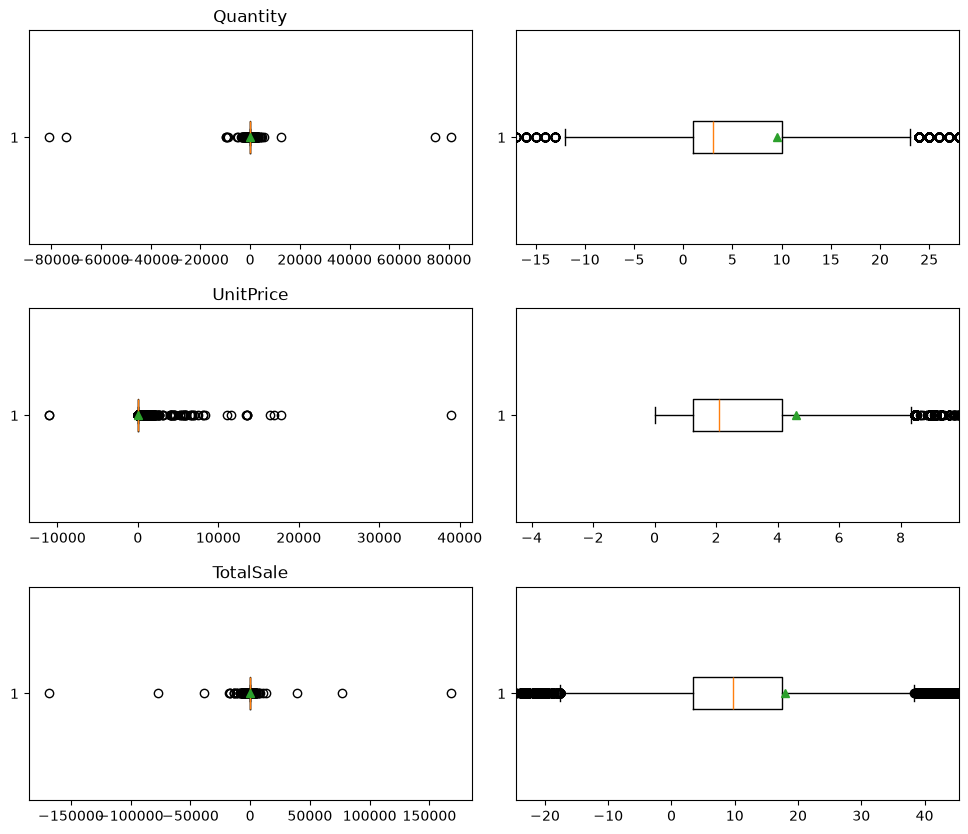

In [14]:
# Boxplots
fig, axs = plt.subplots(3, 2, figsize = (12, 10))
# 1. Quantity
axs[0, 0].boxplot(df['Quantity'], orientation = 'horizontal', showmeans = True)
axs[0, 0].set_title('Quantity')
# 2. UnitPrice
axs[1, 0].boxplot(df['UnitPrice'], orientation = 'horizontal', showmeans = True)
axs[1, 0].set_title('UnitPrice')
# 3. TotalSale
axs[2, 0].boxplot(df['TotalSale'], orientation = 'horizontal', showmeans = True)
axs[2, 0].set_title('TotalSale')
# 1.1. Ampliación Quantity
#
def iqr_lim(dataFrame):
    q1, q3 = dataFrame.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    return (iqr, lim_inf, lim_sup)
iqr1, lim_inf1, lim_sup1 = iqr_lim(df['Quantity'])
#
axs[0, 1].boxplot(df['Quantity'], orientation = 'horizontal', showmeans = True)
axs[0, 1].set_xlim(lim_inf1 - 0.5 * iqr1, lim_sup1 + 0.5 * iqr1)
# 2.1. Ampliación UnitPrice
iqr2, lim_inf2, lim_sup2 = iqr_lim(df['UnitPrice'])
#
axs[1, 1].boxplot(df['UnitPrice'], orientation = 'horizontal', showmeans = True)
axs[1, 1].set_xlim(lim_inf2 - 0.5 * iqr2, lim_sup2 + 0.5 * iqr2)
# 3.1. Ampliación TotalSale
iqr3, lim_inf3, lim_sup3 = iqr_lim(df['TotalSale'])
#
axs[2, 1].boxplot(df['TotalSale'], orientation = 'horizontal', showmeans = True)
axs[2, 1].set_xlim(lim_inf3 - 0.5 * iqr3, lim_sup3 + 0.5 * iqr3)
plt.subplots_adjust(hspace = 0.3, wspace = 0.1)
plt.show()

In [15]:
# Suma total por países
countryTot = df.groupby('Country').agg(
    totSaleCountry = ('TotalSale', 'sum'),
    nCustomers = ('CustomerID', 'nunique')
).sort_values('totSaleCountry', ascending = False).reset_index()
#
print("Top países con mejor cartera:\n", countryTot.head(3),
      "\n\nPaíses con cartera a revisar:\n", countryTot.tail(3),
     "\n________________________________________________\n")
#
# Suma total por consumidor registrado
customerTot = df.groupby(['CustomerID'])['TotalSale'].sum().sort_values(ascending = False).reset_index()
customerTot = customerTot.merge(df[['CustomerID','Country']].drop_duplicates(),
                                on = 'CustomerID', how = 'left')
#
print("Mejores clientes:\n", customerTot.head(5),
     "\n________________________________________________\n\n",
     "Clientes con cartera a revisar:\n", customerTot.tail(10),
     "\n________________________________________________\n")
#
# Ventas efectivas
df_ef = df.loc[df['TotalSale'] > 0]
# Cuánto representa la venta efectiva con clientes no registrados
customerNan = (
    df_ef.groupby(df_ef['CustomerID'].isna())['TotalSale'].sum().rename(index = {True: 'ND', False: 'D'}).to_frame('sumTotSale')
)
#
percCustomerNan = round(customerNan.at['ND', 'sumTotSale'] * 100 / customerNan['sumTotSale'].sum(), 2)
print("Clientes no registrados con ventas efectivas:\n", percCustomerNan, "%",
     "\n________________________________________________\n")
# Producto más vendido
codeTot = df_ef.groupby(['StockCode'])['TotalSale'].sum().sort_values(ascending = False).reset_index()
#
print("Productos con mayor valor en ventas:\n", codeTot.head(5),
     "\n________________________________________________\n\n",
     "Productos con menor valor en ventas:\n", codeTot.tail(5),
     "\n________________________________________________\n")

Top países con mejor cartera:
           Country  totSaleCountry  nCustomers
0  UNITED KINGDOM     8187806.364        3950
1     NETHERLANDS      284661.540           9
2            EIRE      263276.820           3 

Países con cartera a revisar:
            Country  totSaleCountry  nCustomers
35  CZECH REPUBLIC          707.72           1
36         BAHRAIN          548.40           2
37    SAUDI ARABIA          131.17           1 
________________________________________________

Mejores clientes:
   CustomerID  TotalSale         Country
0      14646  279489.02     NETHERLANDS
1      18102  256438.49  UNITED KINGDOM
2      17450  187482.17  UNITED KINGDOM
3      14911  132572.62            EIRE
4      12415  123725.45       AUSTRALIA 
________________________________________________

 Clientes con cartera a revisar:
      CustomerID  TotalSale         Country
4370      12666    -227.44          ISRAEL
4371      16252    -295.09  UNITED KINGDOM
4372      15802    -451.42  UNITED KINGD

#### 3. Visualización

In [16]:
# Venta neta
yearTotSale = df['TotalSale'].sum()
#
print("Venta neta anual:", yearTotSale)

Venta neta anual: 9747747.934


Las gráficas a continuación, describen el movimiento de ventas para el año de referencia, por día y por mes. Permiten observar picos en ventas y momentos de desembolsos por cancelaciones de pedidos o ajustes de caja. Finalmente, se compara el producto más vendido con respecto al total del mes, considerando solo ventas efectivas.

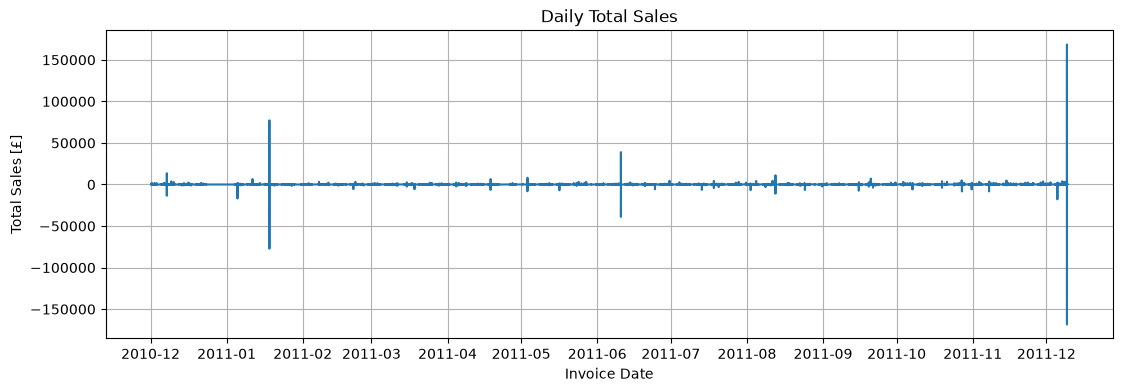

In [17]:
# Serie de tiempo ventas
t = df['InvoiceDate']
s = df['TotalSale']
#
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t, s)
ax.set(xlabel='Invoice Date', ylabel='Total Sales [£]',
       title='Daily Total Sales')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.grid()
fig.savefig("daily_total_sale.png")
plt.show()

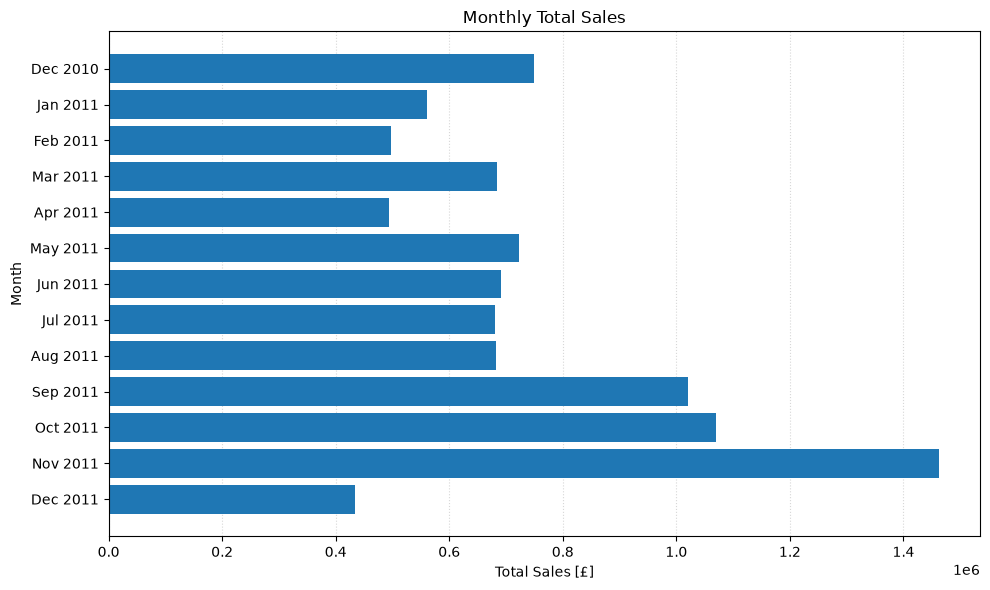

In [18]:
monthTotSales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalSale'].sum()
#
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(monthTotSales.index.strftime('%b %Y'), monthTotSales.values)
ax.invert_yaxis()
ax.set(xlabel='Total Sales [£]', ylabel='Month',
       title='Monthly Total Sales')
ax.grid(axis='x', linestyle=':', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig("monthly_total_sales.png")
plt.show()

In [19]:
# Ventas por mes, con articulo más vendido
## Totales por mes
df_mes = df_ef
df_mes['Month'] = df_mes['InvoiceDate'].dt.to_period('M')
monthProduct = df_mes.groupby('Month').agg(
    TotalItems = ('Quantity', 'sum'),
    TotalSales = ('TotalSale', 'sum')
).reset_index()
## Producto más vendido por mes
ventas_prod = df_mes.groupby(['Month', 'StockCode'], as_index = False).agg(
    Quantity = ('Quantity', 'sum'),
    TotalSale = ('TotalSale', 'sum')
)
top = (ventas_prod
       .sort_values('Quantity', ascending = False)
       .drop_duplicates('Month')
       .rename(columns = {'StockCode': 'TopStockCode', 'Quantity': 'TopQuantity', 'TotalSale': 'TopTotalSale'}))
## Descripciones
desc = (df_mes.dropna(subset = ['Description'])
          .drop_duplicates('StockCode')[['StockCode', 'Description']]
          .rename(columns = {'StockCode': 'TopStockCode'}))
## Tabla de resumen por mes
monthProduct = (monthProduct
           .merge(top, on = 'Month', how = 'left')
           .merge(desc, on = 'TopStockCode', how = 'left'))
monthProduct

,Month,TotalItems,TotalSales,TopStockCode,TopQuantity,TopTotalSale,Description
0,2010-12,359239,823746.140,84077,5195,1174.13,WORLD WAR 2 GLIDERS ASSTD DESIGNS
1,2011-01,387785,691364.560,23166,74215,77183.60,MEDIUM CERAMIC TOP STORAGE JAR
2,2011-02,283555,523631.890,22053,3986,3302.92,EMPIRE DESIGN ROSETTE
3,2011-03,377526,717639.360,85099B,5280,10118.38,JUMBO BAG RED RETROSPOT
4,2011-04,308815,537808.621,84077,10239,2290.89,WORLD WAR 2 GLIDERS ASSTD DESIGNS
5,2011-05,395738,770536.020,22197,6849,5151.63,SMALL POPCORN HOLDER
6,2011-06,389213,761739.900,85099B,3681,7247.98,JUMBO BAG RED RETROSPOT
7,2011-07,401759,719221.191,84568,5019,907.02,GIRLS ALPHABET IRON ON PATCHES
8,2011-08,421770,759138.380,84879,6553,9882.25,ASSORTED COLOUR BIRD ORNAMENT
9,2011-09,570820,1058590.172,85099B,4401,8884.33,JUMBO BAG RED RETROSPOT


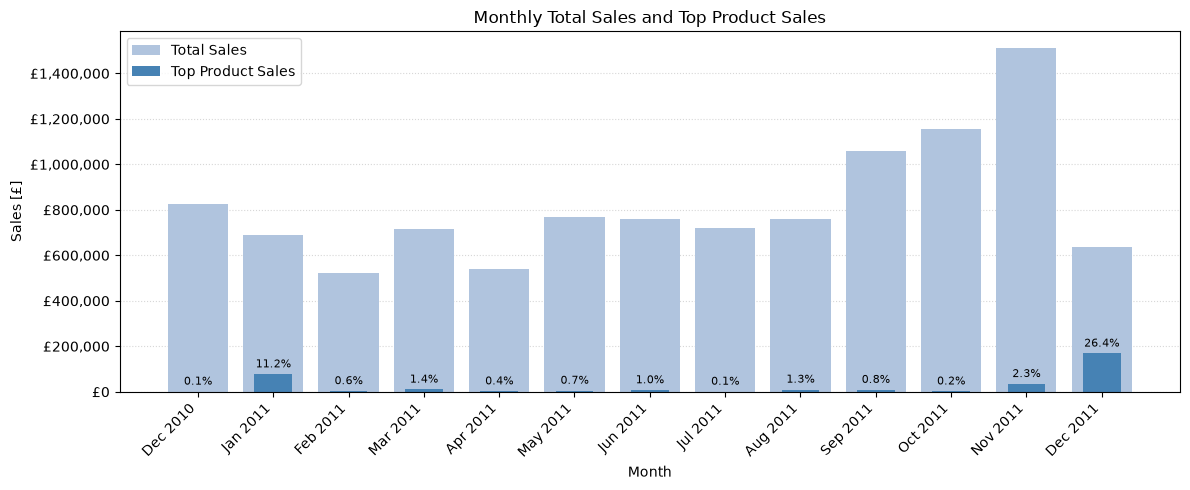

In [21]:
meses = monthProduct['Month'].dt.strftime('%b %Y')

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(meses, monthProduct['TotalSales'], label='Total Sales', color='lightsteelblue')
barras_top = ax.bar(meses, monthProduct['TopTotalSale'], label='Top Product Sales',
                    color='steelblue', width=0.5)

# Porcentaje que representa el producto top sobre el total del mes
prop = monthProduct['TopTotalSale'] / monthProduct['TotalSales']
ax.bar_label(barras_top, labels=[f'{p:.1%}' for p in prop], padding=3, fontsize=8)

ax.set(xlabel='Month', ylabel='Sales [£]',
       title='Monthly Total Sales and Top Product Sales')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_axisbelow(True)
ax.legend()

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig("monthly_total_sales_product.png")
plt.show()